# SciPy Bootcamp — Week 1, Day 3C

##### Sample Size, Power & Experiment Design
##### Type I/II errors, sample size calculation, peeking problem, sequential testing, runtime
##### Visualization philosophy: charts are woven into the analysis at the point of discovery — not appended at the end.
##### Q1 (Sample size calculator — proportions and continuous): Build a reusable sample size calculator function.
# (a) For proportions: baselin...
##### Q2 (MDE sensitivity — how ambition affects sample size): For a conversion rate test with baseline=8%, alpha=0.05, power=0.80:
# (a) Compu...
##### Q3 (The peeking problem — empirical demonstration): Simulate 1000 experiments where H0 is TRUE (no real effect). n=500 per group per...
##### Q4 (Runtime estimation and weekly cycle effects): A new MedPulse feature will be A/B tested.
# Required n per group: 3200 (from sampl...
##### Q5 (Full experiment design brief): Design a complete A/B test from scratch for this scenario:
# 'We want to test wh...


In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

---

### Q1 — Sample size calculator — proportions and continuous

```
Build a reusable sample size calculator function.
# (a) For proportions: baseline=6.5%, MDE=1.5pp, alpha=0.05, power=0.80.
#     Use NormalIndPower from statsmodels.
# (b) For continuous: mean=3.2 min, std=1.8 min, MDE=0.3 min, same alpha/power.
#     Use TTestIndPower from statsmodels.
# (c) Plot a power curve for the proportion test: x=sample size per group (100 to 5000),
#     y=achieved power. Mark the 80% power threshold and the required n.
```


In [ ]:
# Q1: Sample size calculator — proportions and continuous
# Chart + analysis woven together — visualize as you discover


In [30]:
# (a) For proportions: baseline=6.5%, MDE=1.5pp, alpha=0.05, power=0.80.
#     Use NormalIndPower from statsmodels.

baseline    = 0.065
mde         = 0.015
alpha       = 0.05 
power       = 0.80

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
effect_size = proportion_effectsize(baseline + mde, baseline)
n_per_group = NormalIndPower().solve_power(effect_size=effect_size,
                                        alpha=alpha,
                                        power=power,
                                        alternative='larger'
                                            )
print(f'Required n per group (proportions): {int(np.ceil(n_per_group)):,}')

Required n per group (proportions): 3,686


In [11]:
# (b) For continuous: mean=3.2 min, std=1.8 min, MDE=0.3 min, same alpha/power.
#     Use TTestIndPower from statsmodels.

mean    = 3.2
std     = 1.8 
mde_minutes     = 0.3
alpha   = 0.05 
power   = 0.80

from statsmodels.stats.power import TTestIndPower
cohens_d = mde_minutes / std
n_cont = TTestIndPower().solve_power(effect_size=cohens_d,
                                    alpha=alpha,
                                    power=power,
                                    alternative='larger'
                                    )
print(f'Required n per group (continuous):  {int(np.ceil(n_cont)):,}')

Required n per group (continuous):  446


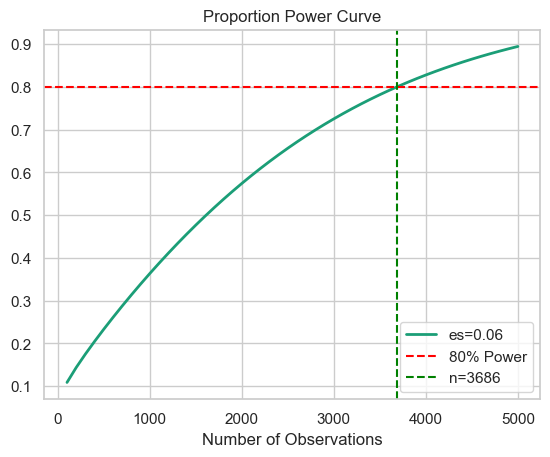

In [36]:
# (c) Plot a power curve for the proportion test: x=sample size per group (100 to 5000),
#     y=achieved power. Mark the 80% power threshold and the required n.

sample_sizes = np.linspace(100, 5000, 50)
NormalIndPower().plot_power(nobs=sample_sizes, effect_size=[effect_size], alpha=0.05, alternative='larger')

plt.axhline(0.8, color='red', linestyle='--', label=f'{int(power*100)}% Power')
plt.axvline(n_per_group, color='green', linestyle='--', label=f'n={int(np.ceil(n_per_group))}')

plt.title("Proportion Power Curve")
plt.legend()
plt.show()

---

### Q2 — MDE sensitivity — how ambition affects sample size

```
For a conversion rate test with baseline=8%, alpha=0.05, power=0.80:
# (a) Compute required n per group for MDE values: 0.5%, 1%, 1.5%, 2%, 3%, 5%.
# (b) Plot required n vs MDE. This is one of the most important charts in experiment design.
# (c) Annotate the point where MDE=2% — the typical business threshold.
# (d) Write a 3-sentence interpretation: what does this chart tell a product manager
#     who wants to detect a 0.5% lift?
```


In [ ]:
# Q2: MDE sensitivity — how ambition affects sample size
# Chart + analysis woven together — visualize as you discover

For a conversion rate test with baseline=8%, alpha=0.05, power=0.80:
# (a) Compute required n per group for MDE values: 0.5%, 1%, 1.5%, 2%, 3%, 5%.
# (b) Plot required n vs MDE. This is one of the most important charts in experiment design.
# (c) Annotate the point where MDE=2% — the typical business threshold.
# (d) Write a 3-sentence interpretation: what does this chart tell a product manager
#     who wants to detect a 0.5% lift?

In [46]:
# (a) Compute required n per group for MDE values: 0.5%, 1%, 1.5%, 2%, 3%, 5%.

mde_range   = np.array([0.005, 0.01, 0.015, 0.02, 0.03, 0.05])
baseline    = 0.08
alpha       = 0.05
power       = 0.8

n_per_group = []

for i in mde_range:
    n = NormalIndPower().solve_power(effect_size=proportion_effectsize(baseline + i, baseline),
                                        alpha=alpha,
                                        power=power,
                                        alternative='larger'
                                            )
    n_per_group.append(n)

df = pd.DataFrame({
    'n'     : np.ceil(n_per_group).astype(int),
    'mde'   : mde_range
})

display(df)

,n,mde
0,37431,0.005
1,9610,0.010
2,4381,0.015
3,2525,0.020
4,1175,0.030
5,459,0.050


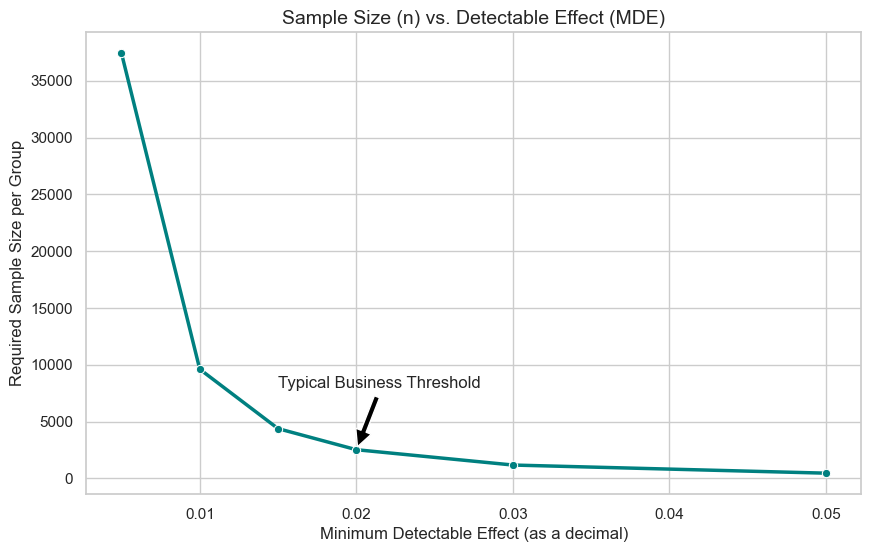

In [55]:
# (b) Plot required n vs MDE. This is one of the most important charts in experiment design.
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.lineplot(data=df, x='mde', y='n', linewidth=2.5, color='teal', marker='o')

plt.xlabel("Minimum Detectable Effect (as a decimal)")
plt.ylabel("Required Sample Size per Group")
plt.title("Sample Size (n) vs. Detectable Effect (MDE)", fontsize=14)

# (c) Annotate the point where MDE=2% — the typical business threshold.
# Add annotations to emphasize the "Cost"
plt.annotate('Typical Business Threshold', xy=(0.02, 2525), xytext=(0.015, 8000),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

In [ ]:
# (d) Write a 3-sentence interpretation: what does this chart tell a product manager
#     who wants to detect a 0.5% lift?

Detecting a 0.5% lift requires a massive investment of over 37,000 users per group, which is nearly four times the traffic needed for a 1% lift. 
This chart warns the Product Manager that chasing such a tiny "needle in a haystack" will significantly increase the time and cost of the experiment. 
Unless the site has enormous traffic, they should consider targeting a larger, more realistic effect size to get results faster.

---

### Q3 — The peeking problem — empirical demonstration

```
Simulate 1000 experiments where H0 is TRUE (no real effect). n=500 per group per day, 14 days.
# (a) For each experiment: run a t-test every day (days 1-14), stop if p<0.05.
#     Count how many experiments incorrectly declare significance.
# (b) Also test each experiment only at the end (day 14). Count false positives.
# (c) Plot the false positive rate vs day of peeking for multiple stopping rules.
# (d) What is the inflated false positive rate from peeking vs the nominal 5%?
# (e) Write a comment describing what would happen to your business if you used peeking.
```


In [ ]:
# Q3: The peeking problem — empirical demonstration
# Chart + analysis woven together — visualize as you discover

In [ ]:
# (a) For each experiment: run a t-test every day (days 1-14), stop if p<0.05.
#     Count how many experiments incorrectly declare significance.
# (b) Also test each experiment only at the end (day 14). Count false positives.
# (d) What is the inflated false positive rate from peeking vs the nominal 5%?

np.random.seed(420)
n_experiments = 1000
daily_n       = 500
days          = 14
alpha         = 0.05

false_positive_peeking  = 0
false_positive_fixed    = 0

for _ in range(n_experiments):
    ctrl_all = np.random.binomial(1, 0.10, daily_n * days)
    trt_all  = np.random.binomial(1, 0.10, daily_n * days)  # same rate!
    
    # Peeking: check every day, stop if significant
    peeked_significant = False
    for d in range(1, days + 1):
        c = ctrl_all[:d * daily_n]
        t = trt_all[:d * daily_n]
        _, p = stats.ttest_ind(c, t)
        if p < alpha:
            peeked_significant = True
            break
    if peeked_significant:
        false_positive_peeking += 1
    
    # Fixed horizon: only look at the end
    _, p_final = stats.ttest_ind(ctrl_all, trt_all)
    if p_final < alpha:
        false_positive_fixed += 1

print(f'False positive rate with peeking:      {false_positive_peeking/n_experiments:.1%}')
print(f'False positive rate with fixed horizon: {false_positive_fixed/n_experiments:.1%}')
print(f'Expected (alpha=0.05):                  5.0%')
print()
print('Peeking can inflate false positives to over 20% — 4-5x the nominal rate.')

False positive rate with peeking:      22.1%
False positive rate with fixed horizon: 5.1%
Expected (alpha=0.05):                  5.0%

Peeking can inflate false positives to over 20% — 4-5x the nominal rate.


In [66]:
# (c) Plot the false positive rate vs day of peeking for multiple stopping rules.

np.random.seed(420)
first_sig_day = []

for _ in range(n_experiments):
    ctrl_all = np.random.binomial(1, 0.10, daily_n * days)
    trt_all  = np.random.binomial(1, 0.10, daily_n * days)
    
    day_it_hit = None
    for d in range(1, days + 1):
        c = ctrl_all[:d * daily_n]
        t = trt_all[:d * daily_n]
        _, p = stats.ttest_ind(c, t)
        if p < alpha:
            day_it_hit = d
            break
    first_sig_day.append(day_it_hit)

In [67]:
daily_counts = [sum(1 for day in first_sig_day if day is not None and day <= d) for d in range(1, days + 1)]
cumulative_fp_rate = [count / n_experiments for count in daily_counts]

df_plot = pd.DataFrame({
    'Day': range(1, days + 1),
    'False Positive Rate': cumulative_fp_rate
})
display(df_plot)

,Day,False Positive Rate
0,1,0.046
1,2,0.086
2,3,0.107
3,4,0.123
4,5,0.145
5,6,0.159
6,7,0.171
7,8,0.182
8,9,0.186
9,10,0.194


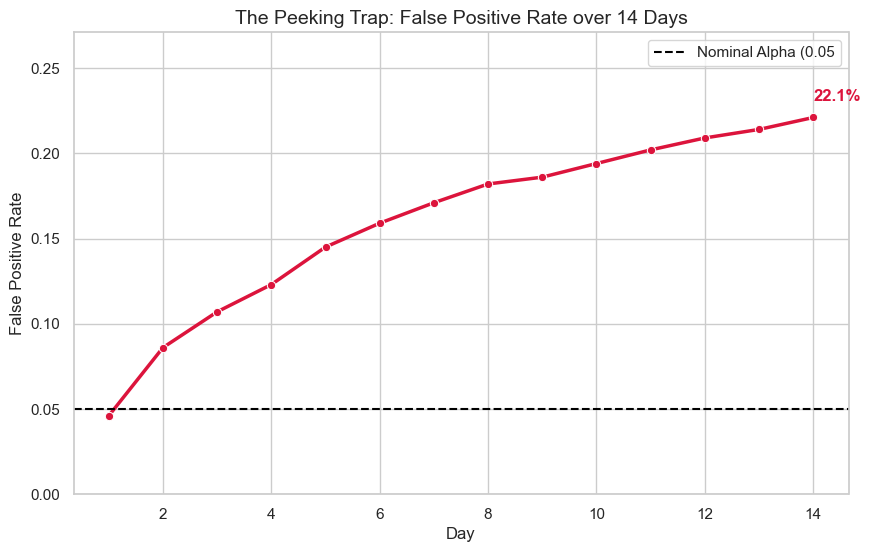

In [68]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.lineplot(data=df_plot, x='Day', y='False Positive Rate', marker='o', color='crimson', linewidth=2.5)

plt.axhline(alpha, color='black', linestyle='--', label=f'Nominal Alpha ({alpha}')

final_rate = cumulative_fp_rate[-1]
plt.text(days, final_rate + 0.01, f'{final_rate:.1%}', weight='bold', color='crimson')

plt.title(f"The Peeking Trap: False Positive Rate over {days} Days", fontsize=14)
plt.ylim(0, max(cumulative_fp_rate) + 0.05)
plt.legend()
plt.show()

# (e) Write a comment describing what would happen to your business if you used peeking.

If your business allows "peeking" to dictate when tests stop, you will eventually fill your product with "ghost features"—changes that looked like winners during a temporary lucky streak but actually provide zero real value. This creates a "leaky bucket" where you think you are improving revenue by 1% every week, yet your overall bottom line remains flat because the wins were never real.

---

### Q4 — Runtime estimation and weekly cycle effects

```
A new MedPulse feature will be A/B tested.
# Required n per group: 3200 (from sample size calculation)
# Daily unique visitors to the feature: 12,000
# Traffic allocation to experiment: 60%
# (a) Calculate days required assuming 50/50 split.
# (b) Simulate weekly traffic variation: Mon-Fri 20% above avg, Sat-Sun 35% below avg.
#     How many CALENDAR days are needed to get 3200 users in each group?
# (c) Plot simulated daily traffic with cumulative sample size overlay.
#     Mark the day when required n is reached.
# (d) Why is it wrong to stop the experiment the moment you hit required n
#     if that moment is a Wednesday?
```


In [ ]:
# Q4: Runtime estimation and weekly cycle effects
# Chart + analysis woven together — visualize as you discover

In [85]:
# (a) Calculate days required assuming 50/50 split.
n_required     = 3200   # per group
daily_visitors = 12000  # total daily visitors to the feature
traffic_split  = 0.60   # 60% of traffic in experiment
group_split    = 0.50   # 50/50 control/treatment

daily_per_group = daily_visitors * traffic_split * group_split
days_required   = np.ceil(n_required / daily_per_group)

print(f'Daily visitors to experiment: {daily_per_group:.0f} per group')
print(f'Days required:                {days_required:.0f} days')
print(f'Minimum runtime:              {days_required/7:.1f} weeks')
print()
print('Rule: always run for at least 1-2 full weekly cycles')
print('to account for day-of-week effects in user behavior.')

Daily visitors to experiment: 3600 per group
Days required:                1 days
Minimum runtime:              0.1 weeks

Rule: always run for at least 1-2 full weekly cycles
to account for day-of-week effects in user behavior.


# (b) Why is it wrong to stop the experiment the moment you hit required n
#     if that moment is a Wednesday?

User Bias: Wednesday users (likely searching for health info during work hours) behave differently than Saturday users (who might be searching for emergency or leisure health info).
Full Business Cycle: You should always run a test for at least 7 full days to ensure your results aren't "polluted" by the specific mindset of weekday vs. weekend visitors.
External Factors: A single news story or health trend on a Tuesday could skew that day's data; a full week smooths out these one-off spikes.

---

### Q5 — Full experiment design brief

```
Design a complete A/B test from scratch for this scenario:
# 'We want to test whether adding a patient review section to MedPulse condition pages
#  increases the rate of users clicking the Find a Doctor button.'
# Write a complete experiment design that includes:
# (a) Null and alternative hypothesis (written out in plain English)
# (b) Primary metric and 2 guardrail metrics
# (c) Required sample size (choose your own realistic baseline and MDE — justify them)
# (d) Estimated runtime given 25,000 daily page views, 40% traffic allocation
# (e) A power curve plot
# (f) List 3 things that could invalidate this experiment
# This is portfolio-ready output — write it as if presenting to a product team.
```


In [ ]:
# Q5: Full experiment design brief
# Chart + analysis woven together — visualize as you discover

# (a) Null and alternative hypothesis (written out in plain English)

H0: adding a patient review section to MedPulse condition pages does not increase the rate of users clicking the Find a Doctor button
Ha: adding a patient review section to MedPulse condition pages does increase the rate of users clicking the Find a Doctor button

# (b) Primary metric and 2 guardrail metrics
Primary metric:
CTR on the Find a Doctor button

2 Guardrail metric:
a. Bounce Rate may increase
b. Ad Revenue/CTR may decrease

In [ ]:
# (c) Required sample size (choose your own realistic baseline and MDE — justify them)

baseline    = 0.0055        # CTR: 0.55%
mde         = 0.0011          # MDE: 0.11% ~ 20% relative lift x 0.55% baseline
alpha       = 0.05 
power       = 0.80

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
effect_size = proportion_effectsize(baseline + mde, baseline)
n_per_group = NormalIndPower().solve_power(effect_size=effect_size,
                                        alpha=alpha,
                                        power=power,
                                        alternative='larger'
                                            )
print(f'Required n per group (proportions): {int(np.ceil(n_per_group)):,}')

Required n per group (proportions): 61,325


In [ ]:
# (d) Estimated runtime given 25,000 daily page views, 40% traffic allocation
n_required     = 61325   # per group
daily_visitors = 25000  # total daily visitors to the feature
traffic_split  = 0.40   # 40% of traffic in experiment
group_split    = 0.50   # 50/50 control/treatment

daily_per_group = daily_visitors * traffic_split * group_split
days_required   = np.ceil(n_required / daily_per_group)

print(f'Daily visitors to experiment: {daily_per_group:.0f} per group')
print(f'Days required:                {days_required:.0f} days')
print(f'Minimum runtime:              {days_required/7:.1f} weeks')
print()
print('Rule: always run for at least 2 full weekly cycles')
print('to account for day-of-week effects in user behavior.')

Daily visitors to experiment: 5000 per group
Days required:                13 days
Minimum runtime:              1.9 weeks

Rule: always run for at least 1-2 full weekly cycles
to account for day-of-week effects in user behavior.


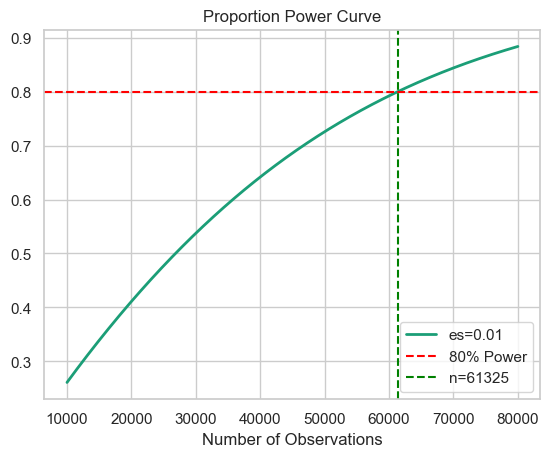

In [83]:
# (e) A power curve plot

sample_sizes = np.linspace(10000,80000,5000)
NormalIndPower().plot_power(nobs=sample_sizes, effect_size=[effect_size], alpha=0.05, alternative='larger')

plt.axhline(0.8, color='red', linestyle='--', label=f'{int(power*100)}% Power')
plt.axvline(n_per_group, color='green', linestyle='--', label=f'n={int(np.ceil(n_per_group))}')

plt.title("Proportion Power Curve")
plt.legend()
plt.show()

# (f) List 3 things that could invalidate this experiment
1. The sample is not randomly selected
2. The peeking problem
3. The duration is not long enough to remove risks related to user bias, business cycle and external factors

Other things to consider:
1. Novelty effect.
2. Cannibalization of ad revenue
3. Interference or Contamination 